In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Color Palette
Colorblindness friendliness was checked on David Nichols' [Coloring for Colorblindness Web Page](https://davidmathlogic.com/colorblind/#%23648FFF-%23785EF0-%23DC267F-%23FE6100-%23FFB000).

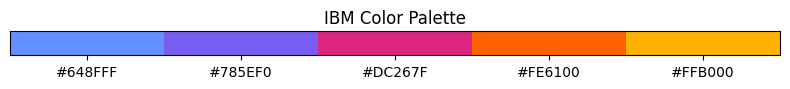

In [3]:
ibm_colors = [
    "#648FFF",
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000",
]

rgb_colors = [mcolors.to_rgba(c) for c in ibm_colors]

fig, ax = plt.subplots(figsize=(8, 1))

for i, color in enumerate(ibm_colors):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color))

ax.set_xlim(0, len(ibm_colors))
ax.set_ylim(0, 1)

ax.set_xticks(np.arange(len(ibm_colors)) + 0.5)
ax.set_xticklabels(ibm_colors, ha="center")

ax.set_yticks([])

ax.set_title("IBM Color Palette")

plt.tight_layout()
plt.show()

mycolors = [rgb_colors[0], rgb_colors[2], rgb_colors[4]]

# Load data

In [4]:
figs_root = Path("../figures/adpkd-validation-screen").resolve().absolute()
if not figs_root.exists():
    figs_root.mkdir(parents=True)

root_path = Path("../data/target_validation").resolve().absolute()

df = (
    pd.read_csv(root_path / "ADPKD-TargetValidationScreen_Batch3791_and_Batch3753.csv")
    .assign(QC_problems=lambda x: x["QC_problems"].fillna("-"))
    .query("QC_problems == '-'")
    .dropna(subset=["obj.Mean(area).um2.meas"])
    .drop(columns=["Name", "QC_problems"])
)

## Normalization

In [5]:
readout = "obj.Mean(area).um2.meas"
method = "median"
norm_array = []

for plate in df.plate_id.unique():
    plate_subset = df.query(f"plate_id == {plate}")
    if method == "mean":
        mean_df = (
            plate_subset.rename(columns={"Stimulant dose": "Stimulant_dose"})
            .groupby(["treatment_type", "Stimulant_dose"])[readout]
            .mean()
            .reset_index()
        )
        solv_control = mean_df.query("treatment_type == 'solvent_ctrl' & Stimulant_dose == 0.1")[
            readout
        ].item()
        stim_control = mean_df.query("treatment_type == 'stim_only' & Stimulant_dose == 2.5")[readout].item()

    if method == "median":
        median_df = (
            plate_subset.rename(columns={"Stimulant dose": "Stimulant_dose"})
            .groupby(["treatment_type", "Stimulant_dose"])[readout]
            .median()
            .reset_index()
        )
        solv_control = median_df.query("treatment_type == 'solvent_ctrl' & Stimulant_dose == 0.1")[
            readout
        ].item()
        stim_control = median_df.query("treatment_type == 'stim_only' & Stimulant_dose == 2.5")[
            readout
        ].item()

    denominator = solv_control - stim_control
    val_array = (
        plate_subset[readout]
        .apply(lambda x: x * -1)
        .add(solv_control)
        .div(denominator)
        .apply(lambda x: x * 100)
    )
    norm_array.extend(val_array.tolist())

df["obj.Mean(area).um2.meas_norm"] = norm_array

# Mann-Whitney U test - Boxplots

## Function definition

In [6]:
from plot_functions import box_mann_whitney_u_no_dt, box_mann_whitney_u

In [7]:
all_stats_results = []

## SLC2A1

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:599: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Z4509024390 0.1µM vs. Z4509024390 1.0µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Z4509024390 0.001µM vs. Z4509024390 1.0µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Z4509024390 1.0µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.319e-02 U_stat=4.400e+01


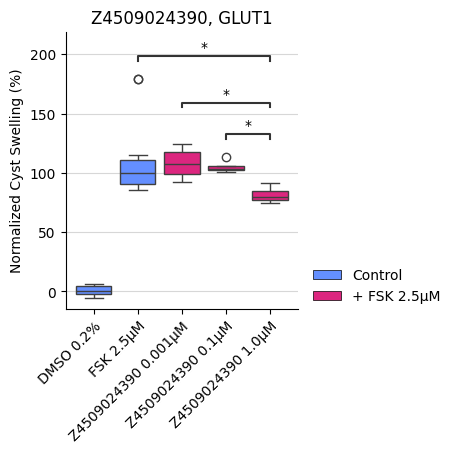

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:599: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Z211311146 0.001µM vs. Z211311146 1.0µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Z211311146 1.0µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.978e-02 U_stat=4.300e+01


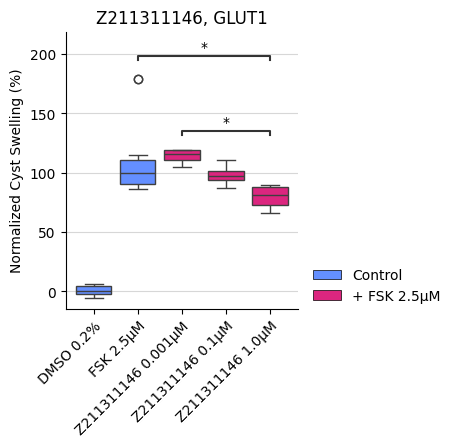

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:599: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



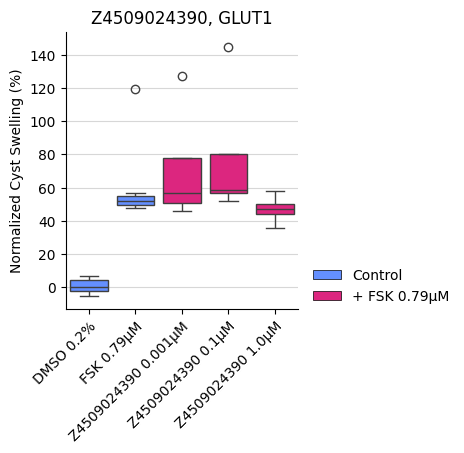

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:599: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



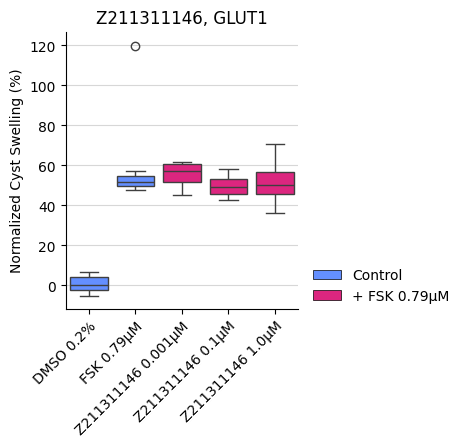

In [8]:
treatments = ["Z4509024390", "Z211311146"]
stats_results = box_mann_whitney_u_no_dt(df, treatments, 1, 2.5, figs_root=figs_root, target="GLU")
all_stats_results.append(stats_results)
stats_results = box_mann_whitney_u_no_dt(df, treatments, 1, 0.79, figs_root=figs_root, target="GLU")
all_stats_results.append(stats_results)

## P2RX7

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:599: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

JNJ-47965567 0.001µM vs. JNJ-47965567 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
FSK 2.5µM vs. JNJ-47965567 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.319e-02 U_stat=4.000e+00


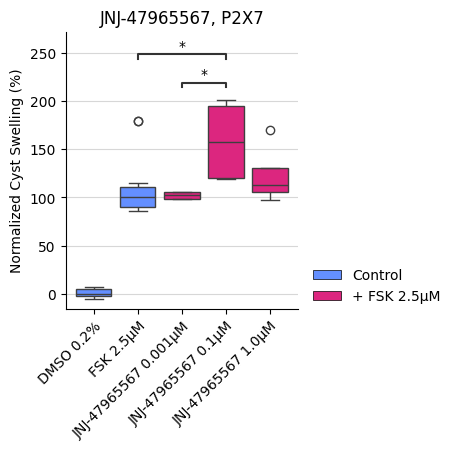

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:599: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



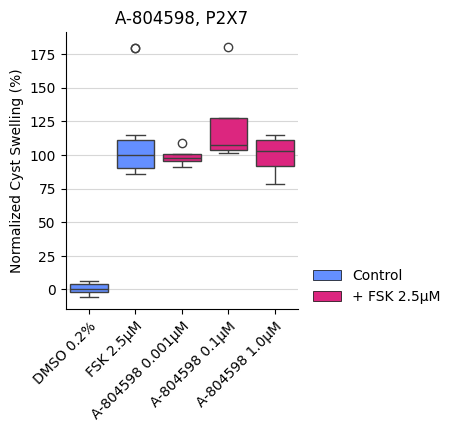

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:599: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



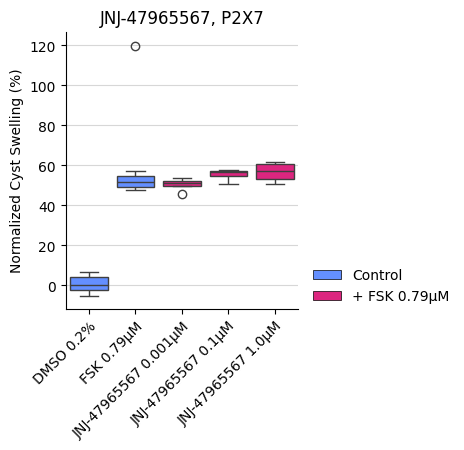

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:599: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



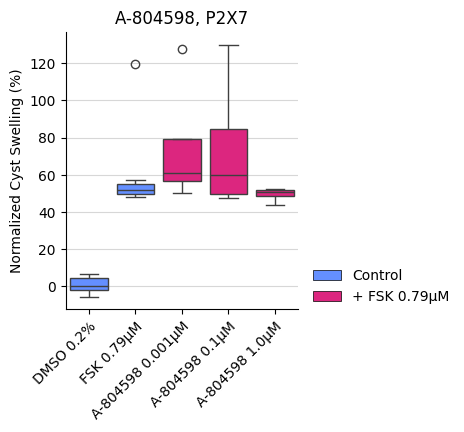

In [9]:
treatments = ["JNJ-47965567", "A-804598"]
stats_results = box_mann_whitney_u_no_dt(df, treatments, 1, 2.5, figs_root=figs_root, target="P2RX7")
all_stats_results.append(stats_results)
stats_results = box_mann_whitney_u_no_dt(df, treatments, 1, 0.79, figs_root=figs_root, target="P2RX7")
all_stats_results.append(stats_results)

## ADORA1

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
FSK 2.5µM vs. DPCPX 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=0.000e+00
DPCPX 0.1µM vs. DPCPX 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
DPCPX 0.001µM vs. DPCPX 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
CPA 1µM vs. DPCPX 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00


/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:431: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


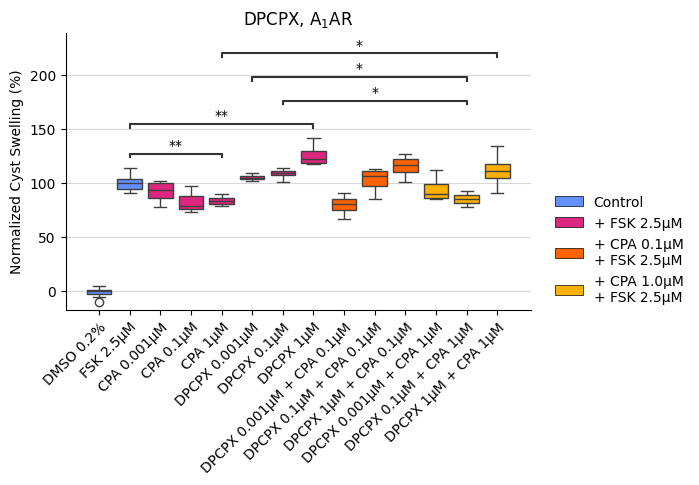

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
Capadenoson 0.001µM vs. Capadenoson 0.1µM CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Capadenoson 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
FSK 2.5µM vs. Capadenoson 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:5.495e-03 U_stat=3.300e+01
Capadenoson 0.1µM vs. Capadenoson 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
Capadenoson 0.001µM vs. Capadenoson 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
CPA 1µM vs. Capadenoson 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01


/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:431: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


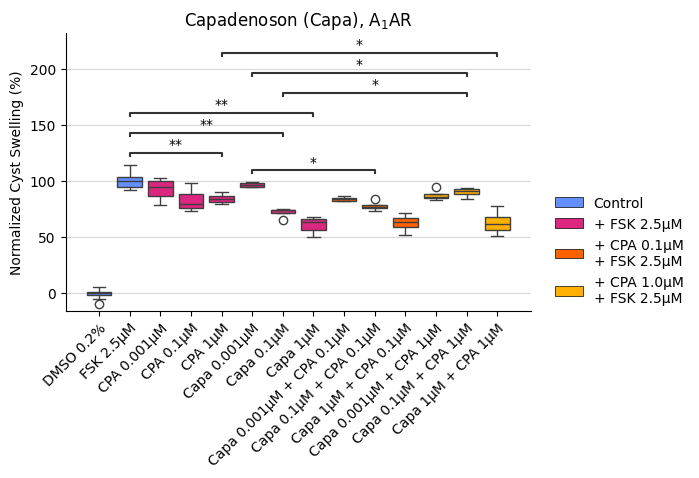

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 0.79µM vs. CPA 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.848e-02 U_stat=2.200e+01
FSK 0.79µM vs. CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.828e-02 U_stat=2.900e+01
DPCPX 0.1µM CPA 0.1µM vs. DPCPX 0.001µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 0.79µM vs. CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.828e-02 U_stat=2.900e+01
CPA 0.1µM vs. DPCPX 0.001µM CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 0.79µM vs. DPCPX 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.081e-03 U_stat=1.000e+00
DPCPX 0.1µM vs. DPCPX 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
CPA 0.1µM vs. DPCPX 1µM CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.8

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:431: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


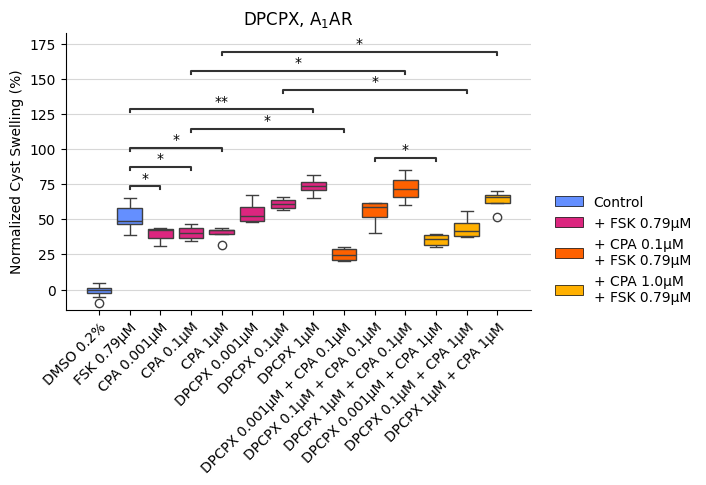

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 0.79µM vs. CPA 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.848e-02 U_stat=2.200e+01
FSK 0.79µM vs. CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.828e-02 U_stat=2.900e+01
Capadenoson 0.1µM CPA 0.1µM vs. Capadenoson 0.001µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
FSK 0.79µM vs. CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.828e-02 U_stat=2.900e+01
Capadenoson 0.001µM vs. Capadenoson 0.1µM CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 0.79µM vs. Capadenoson 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
FSK 0.79µM vs. Capadenoson 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
CPA 0.1µM vs. Capadenoson 0.1µM CPA 0.1µM: Mann-Whitn

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:431: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


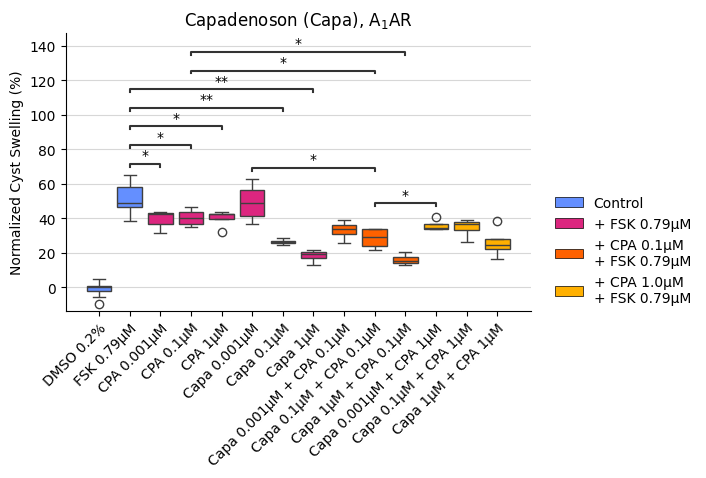

In [10]:
treatments = [
    "DPCPX",
    "Capadenoson",
]

stats_results = box_mann_whitney_u(df, treatments, 2, "CPA", 2.5, figs_root=figs_root, target="A1R")
all_stats_results.append(stats_results)
stats_results = box_mann_whitney_u(df, treatments, 2, "CPA", 0.79, figs_root=figs_root, target="A1R")
all_stats_results.append(stats_results)

## NR3C2

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Aldosterone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.930e-03 U_stat=1.000e+00
FSK 2.5µM vs. Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
FSK 2.5µM vs. Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
Finerenone 1µM Aldosterone 0.1µM vs. Finerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Finerenone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.758e-02 U_stat=4.000e+00
Finerenone 0.001µM vs. Finerenone 0.1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Finerenone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.198e-02 U_stat=2.000e+00
Finerenone 1µM vs.

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:431: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


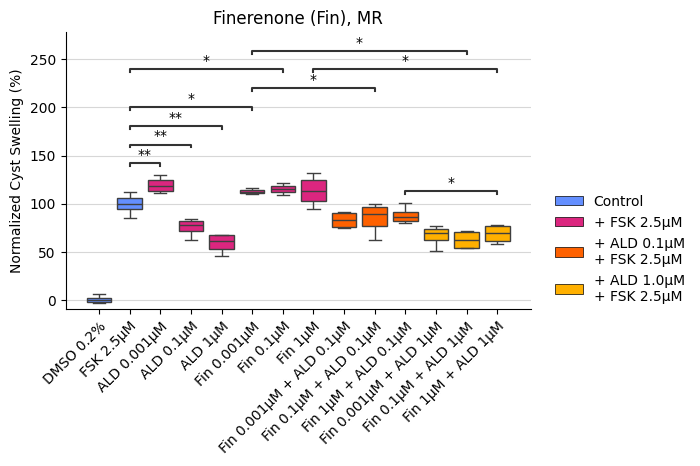

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Aldosterone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.930e-03 U_stat=1.000e+00
FSK 2.5µM vs. Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
FSK 2.5µM vs. Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
Esaxerenone 1µM vs. Esaxerenone 1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.1µM Aldosterone 0.1µM vs. Esaxerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.001µM vs. Esaxerenone 0.1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Esaxerenone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:431: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


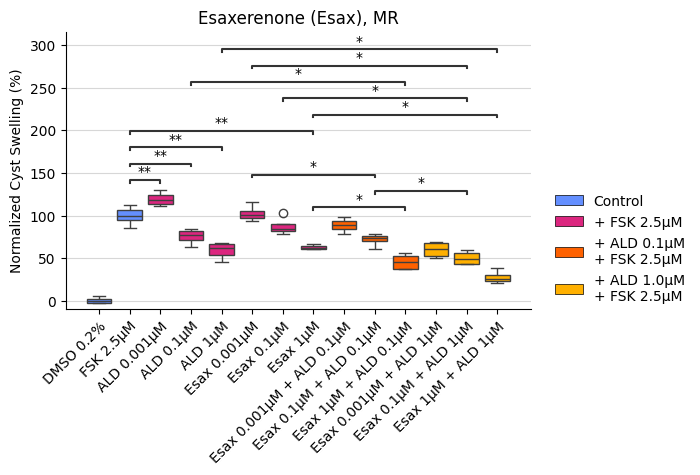

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 0.79µM vs. Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
FSK 0.79µM vs. Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
Finerenone 1µM vs. Finerenone 1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Finerenone 1µM Aldosterone 0.1µM vs. Finerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Finerenone 1µM vs. Finerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Finerenone 0.1µM vs. Finerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Finerenone 0.001µM vs. Finerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:431: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


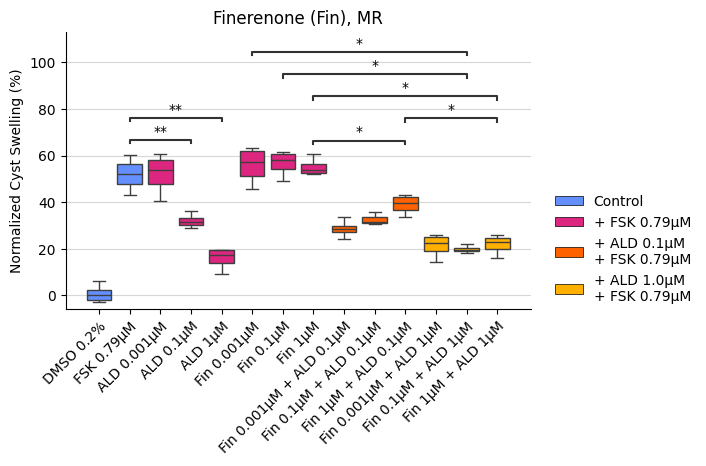

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 0.79µM vs. Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
FSK 0.79µM vs. Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
Esaxerenone 1µM vs. Esaxerenone 1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.1µM vs. Esaxerenone 0.1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 1µM Aldosterone 0.1µM vs. Esaxerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.1µM Aldosterone 0.1µM vs. Esaxerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.001µM vs. Esaxerenone 0.1µM Aldosterone 0.

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:431: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


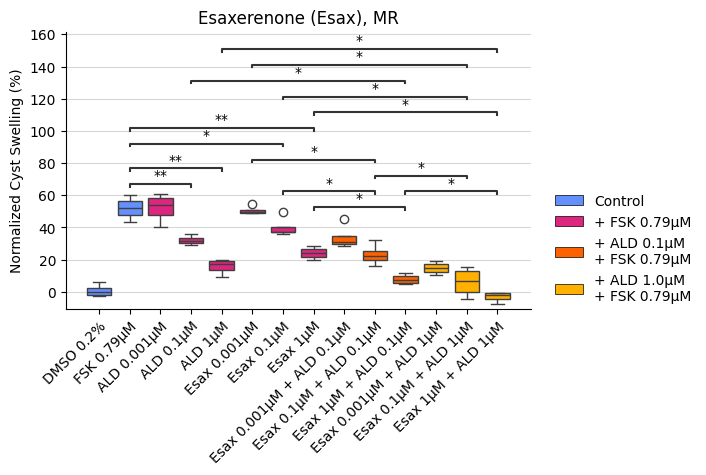

In [11]:
treatments = [
    "Finerenone",
    "Esaxerenone",
]

stats_results = box_mann_whitney_u(df, treatments, 3, "Aldosterone", 2.5, figs_root=figs_root, target="MR")
all_stats_results.append(stats_results)
stats_results = box_mann_whitney_u(df, treatments, 3, "Aldosterone", 0.79, figs_root=figs_root, target="MR")
all_stats_results.append(stats_results)

# Stats results for all targets

In [12]:
all_stats_results = pd.concat(all_stats_results, ignore_index=True)

In [13]:
from itertools import product


def to_latex_scientific(value, precision=1):
    """
    Converts a float into a LaTeX-formatted scientific notation string.

    Args:
        value (float or int): The number to convert.
        precision (int): The number of decimal places for the coefficient.

    Returns:
        str: A LaTeX-formatted string.
    """
    if not isinstance(value, (int, float)):
        raise TypeError("Input must be a number.")

    if value == 0:
        return "$0$"

    # Format the number in scientific notation and split it
    formatted_str = f"{value:.{precision}e}"
    mantissa_str, exponent_str = formatted_str.split("e")

    exponent = int(exponent_str)

    # If the exponent is 0, the scientific notation is unnecessary
    if exponent == 0:
        return f"${mantissa_str}$"

    # Clean up the mantissa if it's a whole number (e.g., "5.0" -> "5")
    mantissa_float = float(mantissa_str)
    if precision == 0 and mantissa_float == int(mantissa_float):
        mantissa_str = str(int(mantissa_float))

    # Construct the LaTeX string
    return f"${mantissa_str} \\times 10^{{{exponent}}}$"


compounds = all_stats_results.compound.unique().tolist()
stimulant_dose = all_stats_results.stimulant_dose.unique().tolist()

for cpd, dose in product(compounds, stimulant_dose):
    stats_subset = all_stats_results.query(f"compound == '{cpd}' & stimulant_dose == {dose}")
    if not stats_subset.empty:
        print(f"## {cpd} - Simulant (FSK) dose: {dose}µM")
        print(
            stats_subset.assign(
                pvalue=lambda x: x.pvalue.apply(lambda y: to_latex_scientific(y, precision=2)),
            )
            .drop(columns=["compound", "stimulant_dose", "double_treat_cpd", "plate_number"])
            .to_markdown(index=False)
        )
        print()

## Z4509024390 - Simulant (FSK) dose: 2.5µM
| group1              | group2              | pvalue                | symbol   | test_description                     | target   |
|:--------------------|:--------------------|:----------------------|:---------|:-------------------------------------|:---------|
| FSK 2.5µM           | Z4509024390 0.001µM | $4.46 \times 10^{-1}$ | ns       | Mann-Whitney-Wilcoxon test two-sided | GLUT1    |
| Z4509024390 0.001µM | Z4509024390 0.1µM   | $8.86 \times 10^{-1}$ | ns       | Mann-Whitney-Wilcoxon test two-sided | GLUT1    |
| Z4509024390 0.1µM   | Z4509024390 1.0µM   | $2.86 \times 10^{-2}$ | *        | Mann-Whitney-Wilcoxon test two-sided | GLUT1    |
| FSK 2.5µM           | Z4509024390 0.1µM   | $5.21 \times 10^{-1}$ | ns       | Mann-Whitney-Wilcoxon test two-sided | GLUT1    |
| Z4509024390 0.001µM | Z4509024390 1.0µM   | $2.86 \times 10^{-2}$ | *        | Mann-Whitney-Wilcoxon test two-sided | GLUT1    |
| FSK 2.5µM           | Z4509024390 1.0

# Cyst Size v.s. Concentration

## Function definition

In [14]:
from plot_functions import plot_with_curves

## SLC2A1

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:111: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"uM": "µM", "pct": "%"})
/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:111: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"u

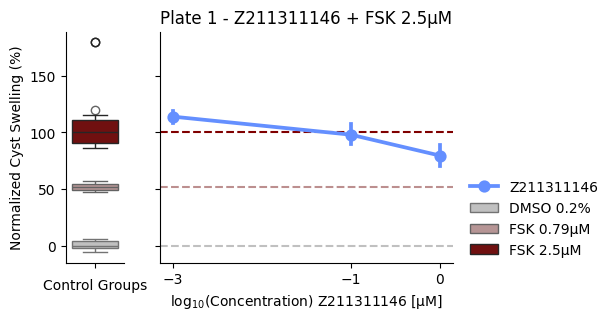

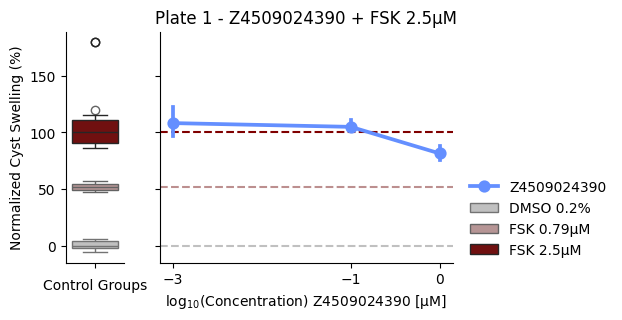

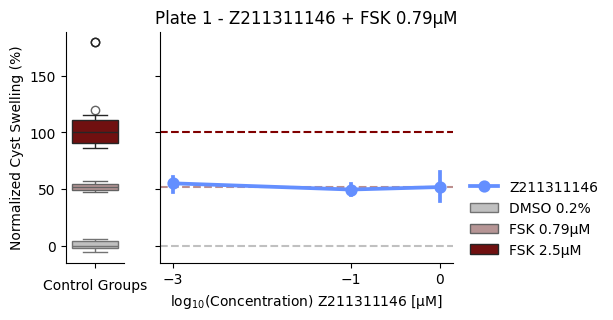

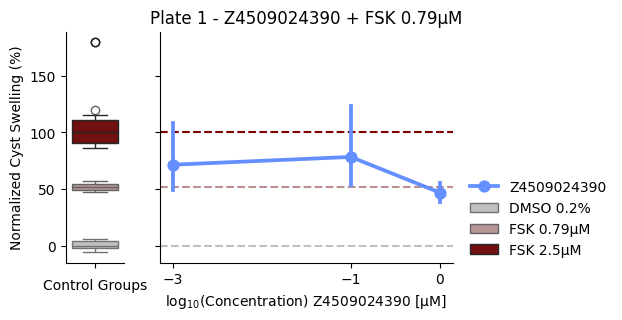

In [15]:
for stim_dose in [2.5, 0.79]:
    _ = plot_with_curves(df, 1, "Z211311146", stim_dose, single_treatment=True, figs_root=figs_root)
    _ = plot_with_curves(df, 1, "Z4509024390", stim_dose, single_treatment=True, figs_root=figs_root)

## P2RX7

/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:111: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"uM": "µM", "pct": "%"})
/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:154: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/03_Target_Validation/plot_functions.py:111: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"u

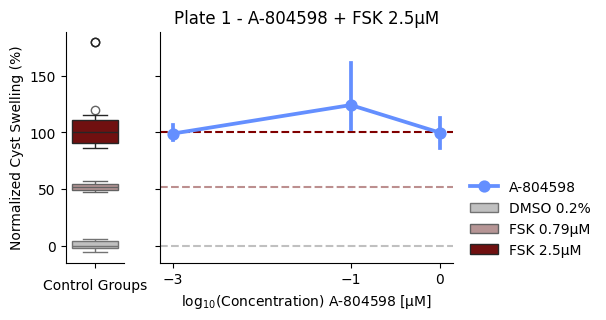

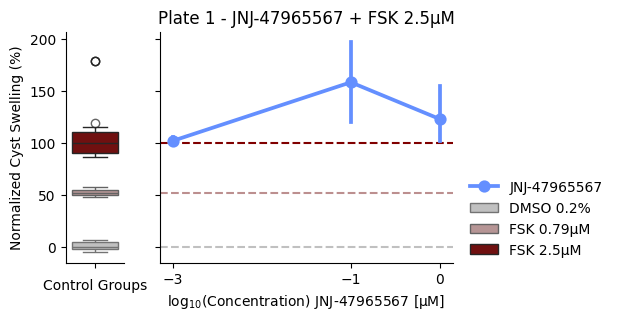

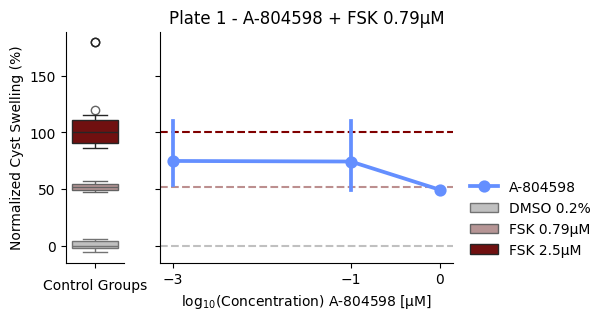

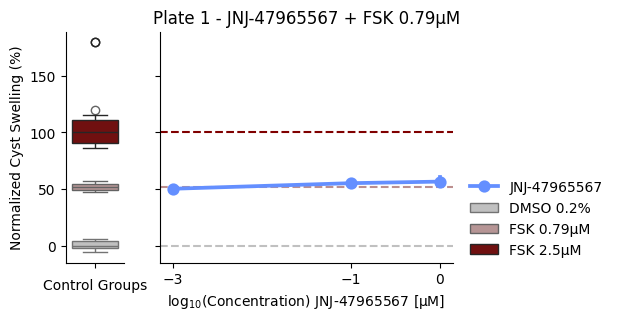

In [16]:
for stim_dose in [2.5, 0.79]:
    _ = plot_with_curves(df, 1, "A-804598", stim_dose, single_treatment=True, figs_root=figs_root)
    _ = plot_with_curves(df, 1, "JNJ-47965567", stim_dose, single_treatment=True, figs_root=figs_root)

## ADORA1

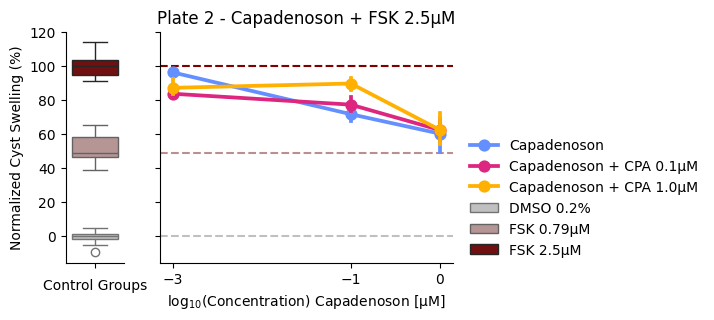

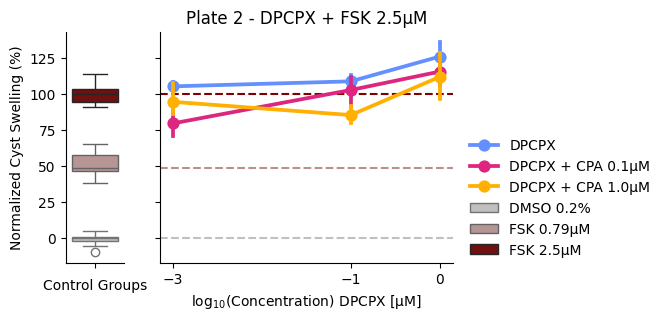

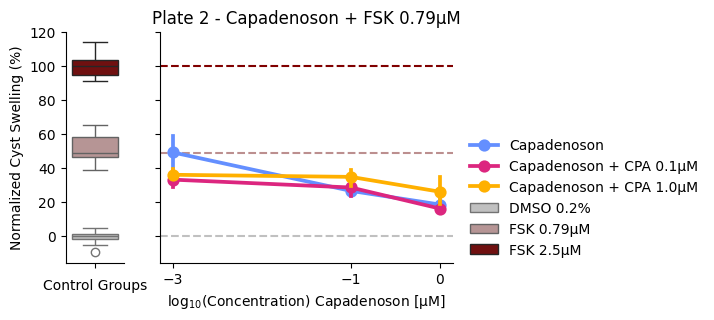

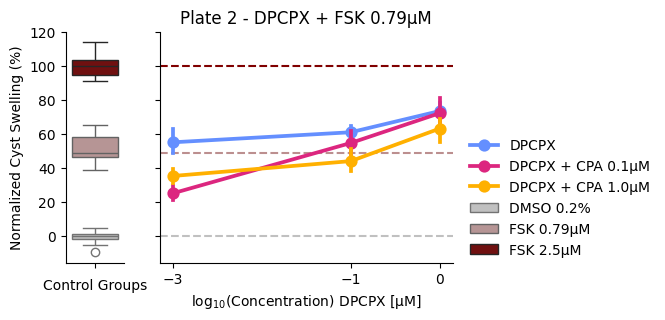

In [17]:
for stim_dose in [2.5, 0.79]:
    plot_with_curves(df, 2, "Capadenoson", stim_dose=stim_dose, figs_root=figs_root)
    plot_with_curves(df, 2, "DPCPX", stim_dose=stim_dose, figs_root=figs_root)

## NR3C2

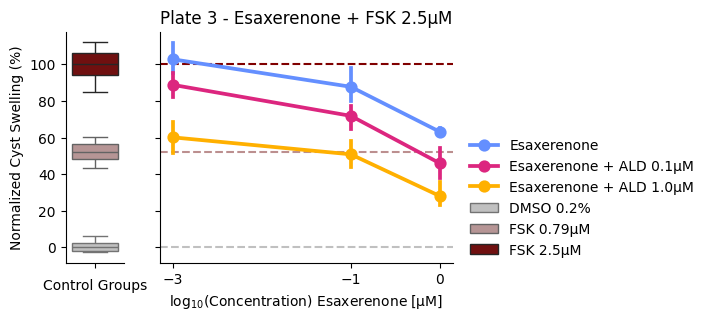

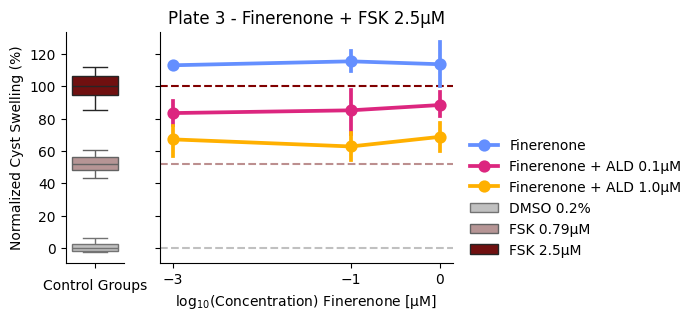

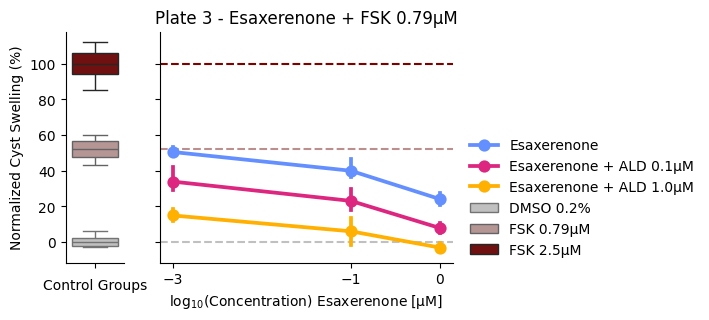

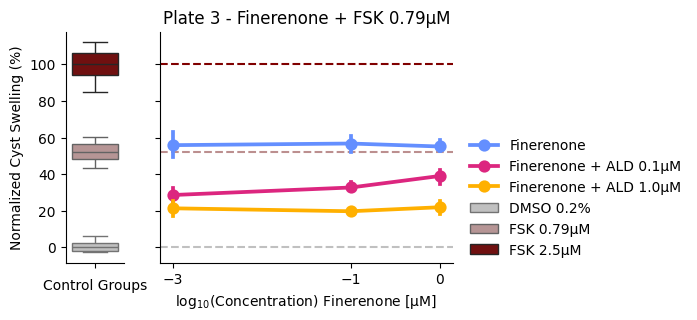

In [18]:
for stim_dose in [2.5, 0.79]:
    _ = plot_with_curves(df, 3, "Esaxerenone", stim_dose=stim_dose, figs_root=figs_root)
    _ = plot_with_curves(df, 3, "Finerenone", stim_dose=stim_dose, figs_root=figs_root)